# Time-resolved analysis

This notebook uses the time-resolved dunking measurements to answer two questions:

1. Which biscuit type is most consistent with each unknown time-resolved dataset (`tr1`, `tr2`, `tr3`)?
2. Once each dataset has been assigned, does a biscuit-specific linear machine-learning model improve the prediction of penetration length compared with the Washburn equation?

The uncertainty column `dL` is used throughout the analysis. First, it is propagated to `L^2` for visualisation. Then it is used directly in reduced chi-squared statistics, so that model errors are judged relative to the experimental uncertainty rather than only by their absolute size.


## Imports


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load and prepare the data

The `dunking-data.csv` file is used to train the biscuit-specific linear models, while `tr-1.csv`, `tr-2.csv` and `tr-3.csv` are treated as the unknown time-resolved datasets. The experimental constants are added to each time-resolved dataframe so that the same inputs can be used for both the Washburn calculation and the machine-learning model.

For plotting in `L^2` space, the uncertainty is propagated using

$$d(L^2) \approx 2L\,dL.$$


In [36]:
dunk = pd.read_csv('dunking-data.csv')
tr1 = pd.read_csv('tr-1.csv')
tr2 = pd.read_csv('tr-2.csv')
tr3 = pd.read_csv('tr-3.csv')

# Experimental conditions for all time-resolved datasets
gamma = 6.78e-2
phi = 1.45
eta = 9.93e-4

tr_data = {
    'tr1': tr1,
    'tr2': tr2,
    'tr3': tr3
}

for label, df in tr_data.items():
    df[['gamma', 'phi', 'eta']] = [gamma, phi, eta]
    df['L2'] = df['L']**2
    df['dL2'] = 2 * df['L'] * df['dL']
    df['dataset'] = label


## Initial visualisation

Plotting `L^2` against time is a useful check as the Washburn equation predicts a linear relationship. The error bars show the propagated measurement uncertainty.


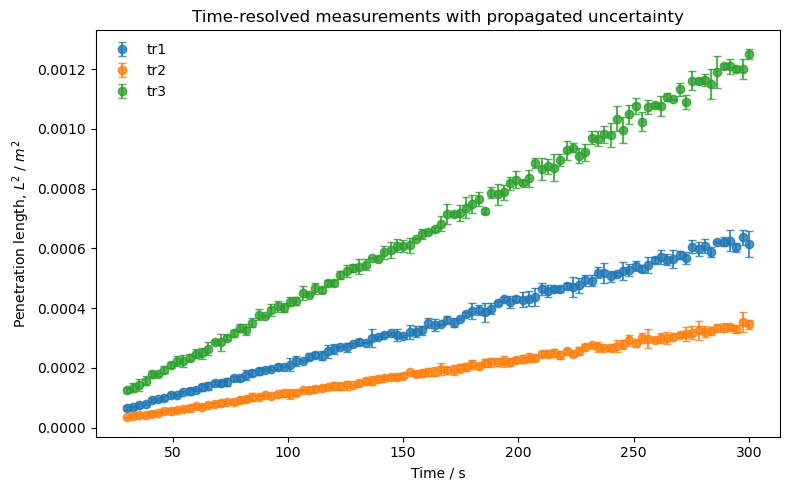

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in tr_data.items():
    ax.errorbar(
        df['t'],
        df['L2'],
        yerr=df['dL2'],
        fmt='o',
        label=label,
        capsize=3,
        alpha=0.8
    )

ax.set_xlabel('Time / s')
ax.set_ylabel('Penetration length, $L^2$ / $m^2$')
ax.set_title('Time-resolved measurements with propagated uncertainty')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

verief the charecteristic relationship

## Assign time-resolved datasets to a biscuit

The first step is to compare each unknown tr trajectory with the Washburn prediction for each biscuit. The biscuit radii come from the microscopy workflow. Each radius gives a different Washburn curve, so the closest curve provides an initial physical assignment.


In [38]:
# Mean pore radii taken from the microscopy analysis workflow
radii = {
    'Hobnob': 4.975634e-07,
    'Rich Tea': 3.133841e-07,
    'Digestive': 7.922873e-07
}

# Consistent colours for plotting
biscuit_colours = {
    'Digestive': 'red',
    'Hobnob': 'orange',
    'Rich Tea': 'blue'
}


def washburn_L(t, r):
    return np.sqrt((gamma * r * t * np.cos(phi)) / (2 * eta))


In [39]:
for label, df in tr_data.items():
    for biscuit, r in radii.items():
        pred_L = washburn_L(df['t'].values, r)

        df[f'{biscuit}_washburn_L'] = pred_L
        df[f'{biscuit}_washburn_L2'] = pred_L**2
        df[f'{biscuit}_residual_L'] = df['L'] - pred_L


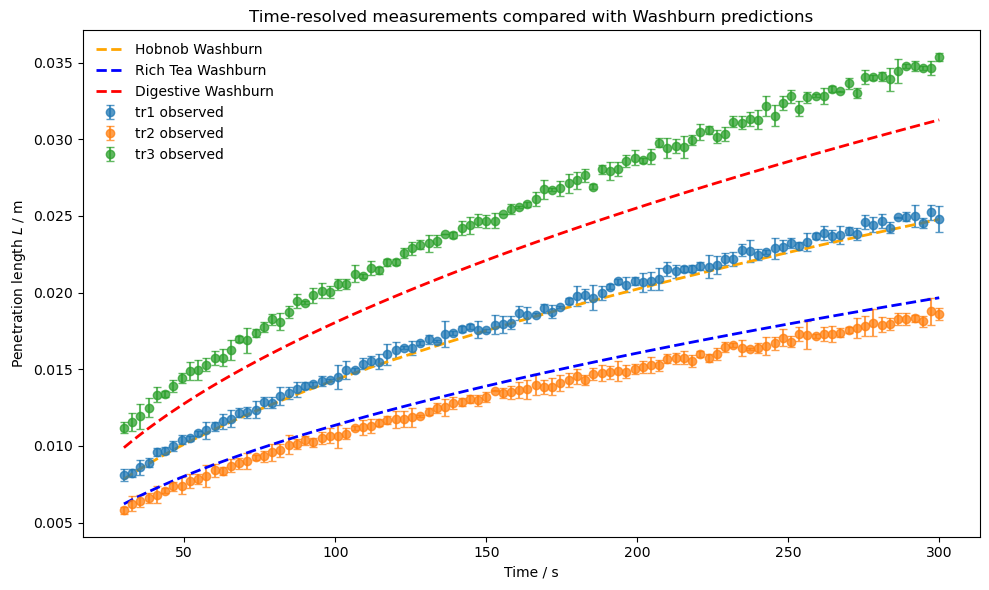

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

# Observed tr1-tr3 measurements
for tr_label, df in tr_data.items():
    ax.errorbar(
        df['t'],
        df['L'],
        yerr=df['dL'],
        fmt='o',
        alpha=0.75,
        capsize=3,
        label=f'{tr_label} observed'
    )

t = np.linspace(min(df['t']), max(df['t']),100)

for biscuit, r in radii.items():
    ax.plot(
        t,
        washburn_L(t, r),#apply washburn
        linestyle='--',
        linewidth=2,
        color=biscuit_colours[biscuit],
        label=f'{biscuit} Washburn'
    )

ax.set_xlabel('Time / s')
ax.set_ylabel('Penetration length $L$ / m')
ax.set_title('Time-resolved measurements compared with Washburn predictions')

ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

## Quantitative assignment using reduced chi-squared

Visual inspection is useful, but assignment should use the measurement uncertainty. I therefore calculated a reduced chi-squared value for every possible pairing between a time-resolved dataset and a biscuit-specific Washburn curve:

$$\chi^2_u = \frac{1}{N-1}\Sigma(\frac{L_{obs}-L_{pred}}{dL})^2.$$

The smallest reduced chi-squared value indicates the biscuit whose Washburn curve best explains the observed trajectory relative to the uncertainty in `L`.


In [41]:
def chi_sq(L_obs, L_pred, dL):
    chi2 = np.sum(((L_obs - L_pred) / dL)**2)
    red = len(L_obs) - 1
    return chi2 / red


In [42]:
chi2_results = []

for tr_label, df in tr_data.items():

    for biscuit, r in radii.items():

        L_pred = washburn_L(df['t'], r)

        # chi-squared using provided uncertainty dL
        red_chi2 = chi_sq(df['L'],L_pred,df['dL']) 


        chi2_results.append({
            'Dataset': tr_label,
            'Biscuit hypothesis': biscuit,
            'Reduced Chi2': red_chi2
        })

chi2_results = pd.DataFrame(chi2_results)

#create summary table
chi2_summary = chi2_results.pivot(
    index='Dataset',
    columns='Biscuit hypothesis',
    values='Reduced Chi2'
)

chi2_summary

Biscuit hypothesis,Digestive,Hobnob,Rich Tea
Dataset,,,
tr1,573.393653,5.388135,510.515385
tr2,1571.451024,374.680225,11.985093
tr3,2495.809936,17425.846147,38686.327979


The reduced chi-squared table supports:

- `tr1` = Hobnob
- `tr2` = Rich Tea
- `tr3` = Digestive

The Hobnob and Rich Tea assignments are relatively clear because their best-fit reduced chi-squared values are very small. The Digestive assignment is still the best of the three options, but the reduced chi-squared value remains very large, suggesting that the Washburn model does not fully explain the `tr3` trajectory within the stated uncertainties.


In [43]:
assignment = {'tr1': 'Hobnob', 'tr2': 'Rich Tea', 'tr3': 'Digestive'}


## Store the assigned Washburn predictions

After assigning each dataset, only the relevant biscuit-specific Washburn prediction is kept for the final comparison. I also calculate residuals both in metres and relative to `dL`, because the latter shows whether deviations are large compared with the measurement uncertainty.


In [44]:
for tr_label, df in tr_data.items():
    best_biscuit = assignment[tr_label]
    r = radii[best_biscuit]

    df['assigned_biscuit'] = best_biscuit
    df['washburn_L'] = washburn_L(df['t'], r)
    df['washburn_L2'] = df['washburn_L']**2
    df['washburn_residual_L'] = df['L'] - df['washburn_L']
    df['residual_over_dL'] = np.abs(df['washburn_residual_L']) / df['dL']

## Train biscuit-specific linear models

compare the physical model with linear regression model for each biscuit using the main dunking dataset. The model predicts `L` from the experimental variables `gamma`, `phi`, `eta` and `t`. This value is then squared

In [45]:
tr_info = {}

for tr_label, df in tr_data.items():
    biscuit = assignment[tr_label]
    tr_info[biscuit] = {
        'dataset': tr_label,
        'df': df,
        'colour': biscuit_colours[biscuit]
    }


In [46]:
def train_biscuit_L2_model(dunk_df, biscuit_name):
    """Train a simple biscuit-specific linear model for L^2."""
    subset = dunk_df[dunk_df['biscuit'] == biscuit_name].copy()

    X = subset[['gamma', 'phi', 'eta', 't']]
    y = subset['L']**2

    model = LinearRegression()
    model.fit(X, y)

    return model


linear_L2_models = {
    biscuit: train_biscuit_L2_model(dunk, biscuit)
    for biscuit in radii.keys()
}

# Apply the assigned biscuit-specific ML model to each time-resolved dataset
for tr_label, df in tr_data.items():
    biscuit = assignment[tr_label]
    model = linear_L2_models[biscuit]

    X_tr = df[['gamma', 'phi', 'eta', 't']]
    ml_L2 = model.predict(X_tr)
    ml_L2 = np.clip(ml_L2, 0, None)

    df['ml_L2'] = ml_L2
    df['ml_L'] = np.sqrt(ml_L2)
    df['ml_residual_L'] = df['L'] - df['ml_L']
    df['ml_residual_over_dL'] = np.abs(df['ml_residual_L']) / df['dL']

## Compare Washburn and machine-learning predictions

The comparison uses both absolute error metrics and uncertainty-scaled metrics. RMSE and MAE show the size of the prediction error, while the mean `|residual|/dL` shows whether the prediction error is large compared with the experimental uncertainty.


In [47]:
rows = []

for biscuit, info in tr_info.items():
    df = info['df']

    rows.append({
        #build metric table
        'Dataset': info['dataset'],
        'Assigned biscuit': biscuit,
        'Washburn RMSE L': np.sqrt(mean_squared_error(df['L'], df['washburn_L'])),
        'ML RMSE L': np.sqrt(mean_squared_error(df['L'], df['ml_L'])),
        'Washburn MAE L': mean_absolute_error(df['L'], df['washburn_L']),
        'ML MAE L': mean_absolute_error(df['L'], df['ml_L']),
        'Mean Washburn |residual|/dL': df['residual_over_dL'].mean(),
        'Mean ML |residual|/dL': df['ml_residual_over_dL'].mean(),
        'Washburn RMSE L2': np.sqrt(mean_squared_error(df['L2'], df['washburn_L2'])),
        'ML RMSE L2': np.sqrt(mean_squared_error(df['L2'], df['ml_L2'])),
        'Washburn R2 L2': r2_score(df['L2'], df['washburn_L2']),
        'ML R2 L2': r2_score(df['L2'], df['ml_L2'])
    })

tr_metrics = pd.DataFrame(rows)
tr_metrics

,Dataset,Assigned biscuit,Washburn RMSE L,ML RMSE L,Washburn MAE L,ML MAE L,Mean Washburn |residual|/dL,Mean ML |residual|/dL,Washburn RMSE L2,ML RMSE L2,Washburn R2 L2,ML R2 L2
0,tr1,Hobnob,0.000428,0.000209,0.000375,0.000169,1.435650,0.676290,0.000017,0.000008,0.989141,0.997490
1,tr2,Rich Tea,0.000828,0.001586,0.000788,0.001495,2.493998,4.753433,0.000026,0.000052,0.916714,0.666501
2,tr3,Digestive,0.002916,0.001660,0.002809,0.001612,16.362453,9.292887,0.000159,0.000091,0.760121,0.921237


## Visual comparison

The next two plots compare the observed measurements with the Washburn and machine-learning predictions. The first plot is shown in `L` space, which is closest to the original measured variable. The second is shown in `L^2` space, where the linear model was trained and where the Washburn equation should be linear.


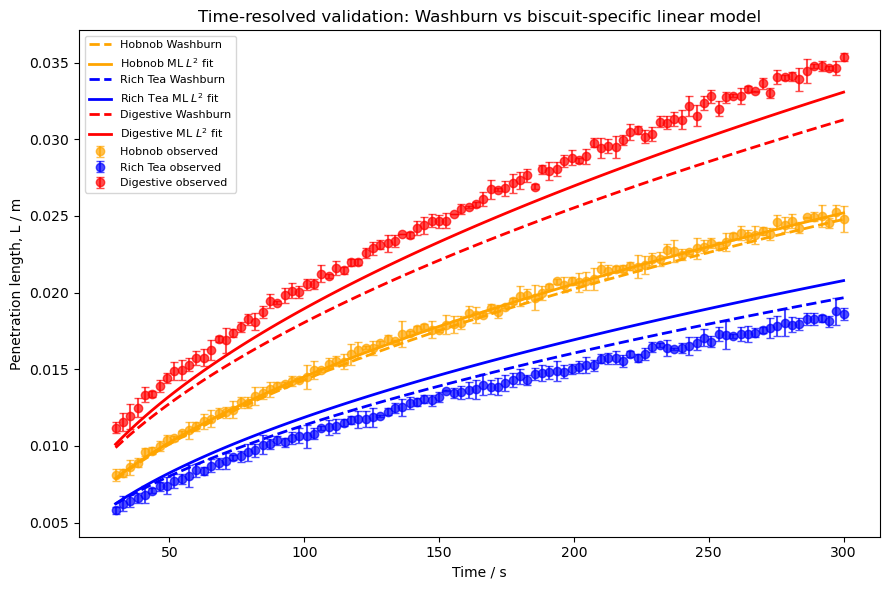

In [48]:
fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.errorbar(
        df['t'],
        df['L'],
        yerr=df['dL'],
        fmt='o',
        color=colour,
        alpha=0.7,
        capsize=3,
        label=f'{biscuit} observed'
    )

    ax.plot(
        df['t'],
        df['washburn_L'],
        color=colour,
        linestyle='--',
        linewidth=2,
        label=f'{biscuit} Washburn'
    )

    ax.plot(
        df['t'],
        df['ml_L'],
        color=colour,
        linestyle='-',
        linewidth=2,
        label=f'{biscuit} ML $L^2$ fit'
    )

ax.set_xlabel("Time / s")
ax.set_ylabel("Penetration length, L / m")
ax.set_title("Time-resolved validation: Washburn vs biscuit-specific linear model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

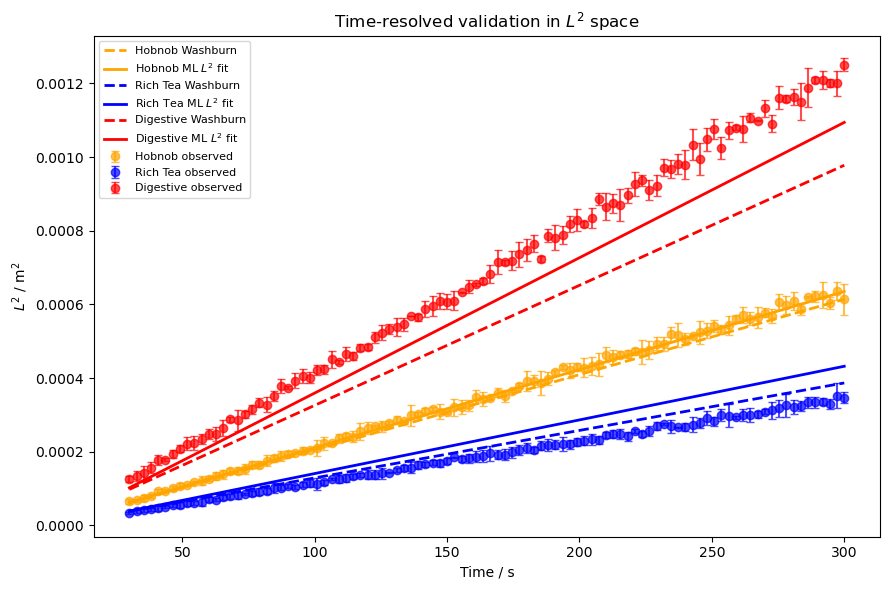

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.errorbar(
        df['t'],
        df['L2'],
        yerr=df['dL2'],
        fmt='o',
        color=colour,
        alpha=0.7,
        capsize=3,
        label=f'{biscuit} observed'
    )

    ax.plot(
        df['t'],
        df['washburn_L2'],
        color=colour,
        linestyle='--',
        linewidth=2,
        label=f'{biscuit} Washburn'
    )

    ax.plot(
        df['t'],
        df['ml_L2'],
        color=colour,
        linestyle='-',
        linewidth=2,
        label=f'{biscuit} ML $L^2$ fit'
    )

ax.set_xlabel("Time / s")
ax.set_ylabel(r"$L^2$ / m$^2$")
ax.set_title(r"Time-resolved validation in $L^2$ space")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Residual analysis

Residual plots help show whether the error is random or systematic/compounding. A good model has residuals scattered around zero without a strong trend over time.


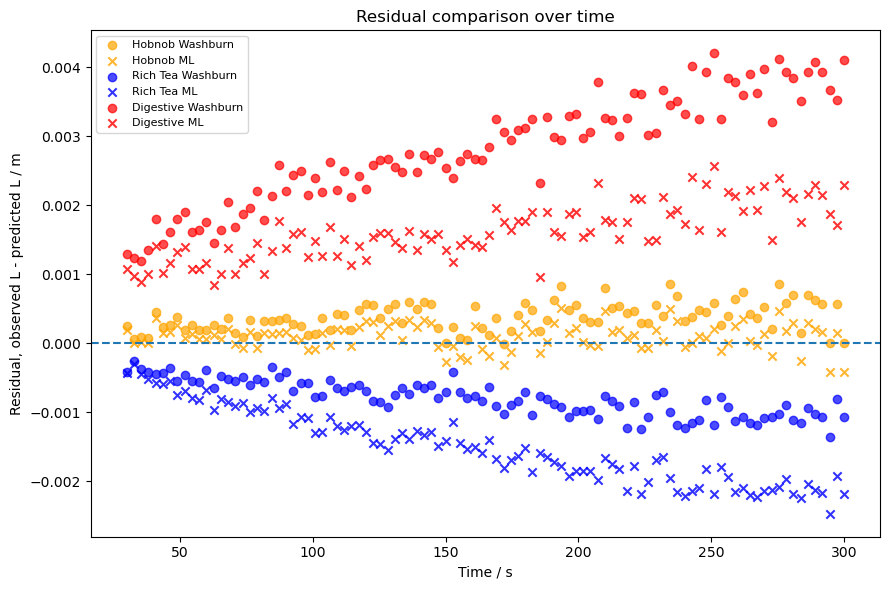

In [50]:
# residuals plot unused in report but useful 

fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.scatter(
        df['t'],
        df['washburn_residual_L'],
        color=colour,
        marker='o',
        alpha=0.7,
        label=f'{biscuit} Washburn'
    )

    ax.scatter(
        df['t'],
        df['ml_residual_L'],
        color=colour,
        marker='x',
        alpha=0.8,
        label=f'{biscuit} ML'
    )

ax.axhline(0, linestyle='--')
ax.set_xlabel("Time / s")
ax.set_ylabel("Residual, observed L - predicted L / m")
ax.set_title("Residual comparison over time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

here it can be seen that both Hobnob models are effective, with significant faults observed in Digestive and Rich Tea varying between Lin Reg and Washburn model errors

## Final summary

This final table combines the main comparison metrics. The RMSE improvement is positive when the machine-learning model performs better than Washburn and negative when it performs worse.

can be found in tab4 in the report

In [51]:
def reduced_chi_sq(y_obs, y_pred, dy, n_params=0):
    chi2 = np.sum(((y_obs - y_pred) / dy) ** 2)
    dof = len(y_obs) - n_params
    return chi2 / dof


rows = []

for biscuit, info in tr_info.items():
    df = info['df']

    washburn_rmse = np.sqrt(mean_squared_error(df['L'], df['washburn_L']))
    ml_rmse = np.sqrt(mean_squared_error(df['L'], df['ml_L']))

    rows.append({
        'Dataset': info['dataset'],
        'Assigned biscuit': biscuit,

        'Washburn RMSE L': washburn_rmse,
        'ML RMSE L': ml_rmse,
        'RMSE improvement (%)': 100 * (washburn_rmse - ml_rmse) / washburn_rmse,

        'Mean Washburn |residual|/dL': df['residual_over_dL'].mean(),
        'Mean ML |residual|/dL': df['ml_residual_over_dL'].mean(),

        'Washburn reduced chi2': reduced_chi_sq(
            df['L'], df['washburn_L'], df['dL']
        ),
        'ML reduced chi2': reduced_chi_sq(
            df['L'], df['ml_L'], df['dL']
        )
    })

summary_table = pd.DataFrame(rows)
summary_table

,Dataset,Assigned biscuit,Washburn RMSE L,ML RMSE L,RMSE improvement (%),Mean Washburn |residual|/dL,Mean ML |residual|/dL,Washburn reduced chi2,ML reduced chi2
0,tr1,Hobnob,0.000428,0.000209,51.178912,1.435650,0.676290,5.334253,1.240673
1,tr2,Rich Tea,0.000828,0.001586,-91.560606,2.493998,4.753433,11.865242,43.329566
2,tr3,Digestive,0.002916,0.001660,43.076371,16.362453,9.292887,2470.851837,817.307228


## Conclusion

The reduced chi-squared assignment identifies `tr1` as Hobnob, `tr2` as Rich Tea and `tr3` as Digestive. The model comparison is more mixed. The linreg model improves the RMSE for Hobnob (`tr1`) and Digestive (`tr3`), but it performs worse for Rich Tea (`tr2`).
